In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

from simses.interpolation import interp1d_scalar

# OCV & Vhys

In [2]:
DATA = Path(
    r"./data/124_02_pOCV_C100_LFP_Haidi_YF047.txt"
)

In [3]:
df = pd.read_csv(
    filepath_or_buffer=DATA,
    sep="\t",
    skiprows=32,
    encoding="latin1",
)
df

,~Time[s],DataSet,t-Step[s],Line,Command,U[V],I[A],Ah[Ah],Ah-Step,T1[°C],Cyc-Count,State
0,0.001000,1,0.001000,2,CalcOnce,3.295581,0.000000,0.000000,0.000000,25.62006,1,2
1,0.002000,2,0.001000,3,CalcOnce,3.295391,0.000000,0.000000,0.000000,25.62006,1,2
2,0.003000,3,0.001000,4,CalcOnce,3.295581,0.000000,0.000000,0.000000,25.62006,1,2
3,0.004000,4,0.001000,5,CalcOnce,3.295391,0.000000,0.000000,0.000000,25.62006,1,2
4,0.005009,5,0.001008,6,CalcOnce,3.295391,0.000000,0.000000,0.000000,25.62006,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
147012,738546.733504,147013,3220.000000,19,Charge,3.348963,0.599959,-0.000179,0.536666,25.93313,1,1
147013,738556.733504,147014,3230.000000,19,Charge,3.348963,0.599942,0.001487,0.538333,25.97872,1,1
147014,738566.733504,147015,3240.000000,19,Charge,3.348963,0.600040,0.003154,0.540000,25.85106,1,1
147015,738567.745360,147016,3241.011856,19,Charge,3.348963,0.599968,0.003323,0.540168,25.84498,1,110


In [4]:
df["SOC"] = np.nan

charge_mask = df["Line"] == 11
discharge_mask = df["Line"] == 14

Q_charge = df[charge_mask]["Ah-Step"].max()
Q_discharge = abs(df[discharge_mask]["Ah-Step"].min())

charge_ah = df.loc[charge_mask, "Ah-Step"]

charge_start = charge_ah.iloc[0]
charge_end = charge_ah.iloc[-1]

df.loc[charge_mask, "SOC"] = (charge_ah - charge_start) / (charge_end - charge_start)

discharge_ah = df.loc[discharge_mask, "Ah-Step"]

discharge_start = discharge_ah.iloc[0]
discharge_end = discharge_ah.iloc[-1]

df.loc[discharge_mask, "SOC"] = (discharge_ah - discharge_end) / (discharge_start - discharge_end)

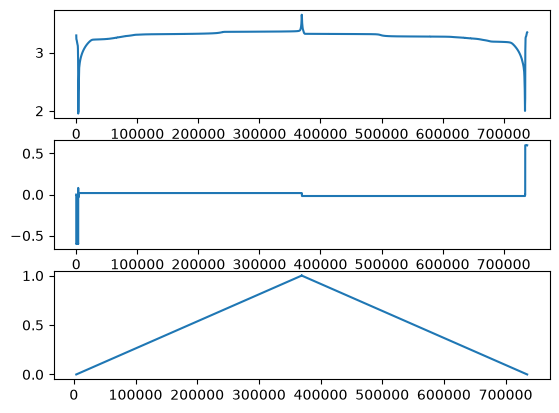

In [5]:
x = df["~Time[s]"]


plt.subplot(311)

plt.plot(x, df["U[V]"])

plt.subplot(312)

plt.plot(x, df["I[A]"])

plt.subplot(313)

plt.plot(x, df["SOC"])

In [6]:
ocv_charge = df.loc[charge_mask, ["SOC", "U[V]"]].copy()

ocv_discharge = df.loc[discharge_mask, ["SOC", "U[V]"]].copy()

ocv = df.loc[df["SOC"].notna(), ["SOC", "U[V]"]].copy()

<Axes: xlabel='SOC'>

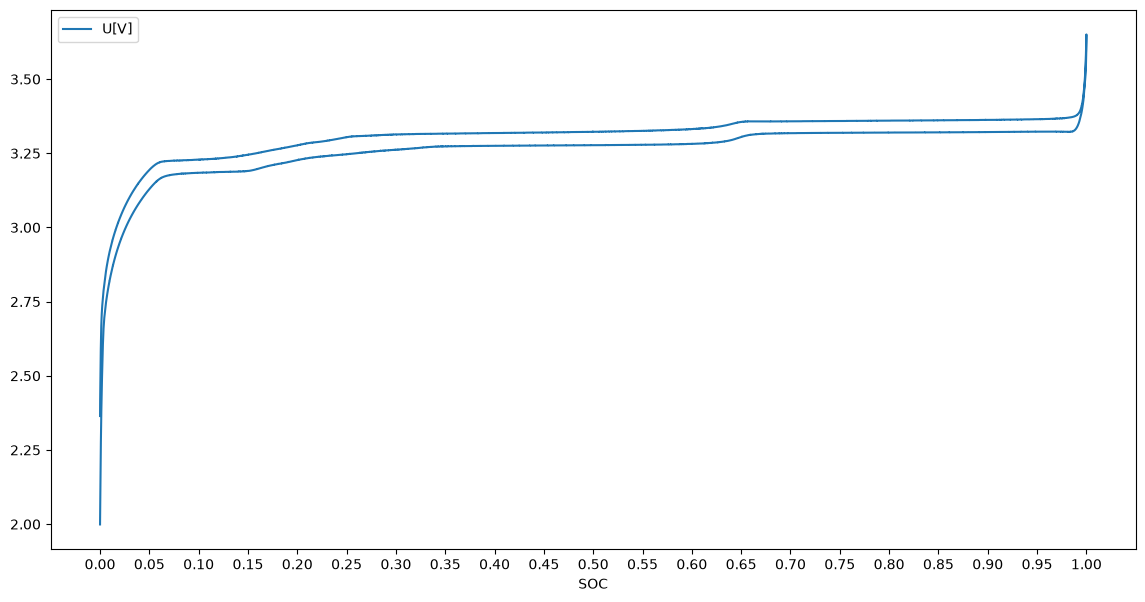

In [7]:
ocv.plot(x="SOC", y="U[V]", xticks=np.arange(0.0, 1.01, 0.05), figsize=(14, 7))

In [ ]:
soc_lut = np.arange(0.0, 1.01, 0.01).tolist()
ocv_lut = []
hys_lut = []

v_charge = ocv_charge.sort_values("SOC")["U[V]"].tolist()
soc_charge = ocv_charge.sort_values("SOC")["SOC"].tolist()

v_discharge = ocv_discharge.sort_values("SOC")["U[V]"].tolist()
soc_discharge = ocv_discharge.sort_values("SOC")["SOC"].tolist()

for soc in soc_lut:
    v_ch = interp1d_scalar(soc, soc_charge, v_charge)

    v_dch = interp1d_scalar(soc, soc_discharge, v_discharge)

    ocv_lut.append((v_ch + v_dch) / 2)
    hys_lut.append((v_ch - v_dch) / 2)

n_trunc = 5  # 5% truncation from both ends
hys_lut[:n_trunc] = [hys_lut[n_trunc]] * n_trunc
hys_lut[-n_trunc:] = [hys_lut[-n_trunc - 1]] * n_trunc

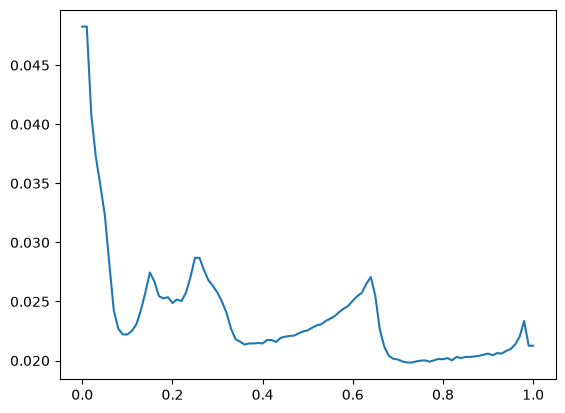

In [11]:
plt.plot(soc_lut, hys_lut)

In [ ]:
lut = pd.DataFrame({
    "SOC": soc_lut,
    "OCV": ocv_lut,
    "HystV": hys_lut,
})

save_path = r"./data/haidi_ocv_hys.csv"
# lut.to_csv(save_path, index=False)

# Rint

In [ ]:
GITT_DIR = Path(r"C:\Users\Piotr\Desktop\Uni\hiwi-bat\Materials\20 Measurements\03_GITT")
GITT_COLUMNS = ["~Time[s]", "Line", "U[V]", "I[A]", "Ah[Ah]", "Cyc-Count"]

GITT_FILES = sorted(path for path in GITT_DIR.glob("*Haidi*.txt") if "sc" not in path.name.lower())

gitt_measurements = {}

for data_path in GITT_FILES:
    measurement = pd.read_csv(
        filepath_or_buffer=data_path,
        sep="\t",
        skiprows=32,
        encoding="latin1",
        usecols=GITT_COLUMNS,
    )

    Q = measurement["Ah[Ah]"].max() - measurement["Ah[Ah]"].min()
    measurement["SOC"] = ((measurement["Ah[Ah]"] - measurement["Ah[Ah]"].min()) / Q).clip(0.0, 1.0)

    gitt_measurements[data_path.stem] = measurement

gitt_measurements.keys()

dict_keys(['105_03_GITT_LFP_Haidi_YF011', '106_03_GITT_LFP_Haidi_YF015', '107_03_GITT_LFP_Haidi_YF022'])

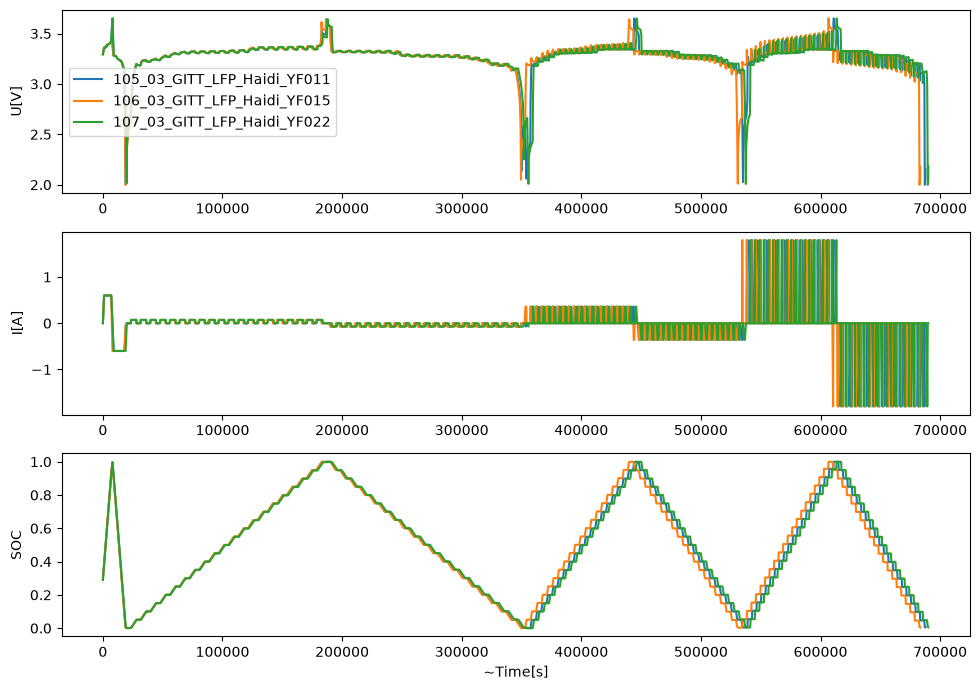

In [ ]:
fig, axes = plt.subplots(3, 1, sharex=False, figsize=(10, 7))

for recording, measurement in gitt_measurements.items():
    overview = measurement.iloc[::1000]
    x = overview["~Time[s]"]

    axes[0].plot(x, overview["U[V]"], label=recording)
    axes[1].plot(x, overview["I[A]"])
    axes[2].plot(x, overview["SOC"])

axes[0].set_ylabel("U[V]")
axes[1].set_ylabel("I[A]")
axes[2].set_ylabel("SOC")
axes[2].set_xlabel("~Time[s]")
axes[0].legend()
plt.tight_layout()

In [ ]:
pulse_edge_lines = [22, 33, 45, 56, 68, 79]
pulses = np.arange(1, 21, 1)


def extract_rint_points(measurement, recording):
    events = measurement[measurement["Line"].isin(pulse_edge_lines) & measurement["Cyc-Count"].isin(pulses)].copy()

    events["sample"] = events.groupby(["Line", "Cyc-Count"]).cumcount()
    edges = events[events["sample"] < 2]

    edge = edges.set_index(["Line", "Cyc-Count", "sample"])[["U[V]", "I[A]", "SOC"]].unstack("sample")

    rint = pd.DataFrame(index=edge.index)
    rint["Rint[Ohm]"] = (edge["U[V]", 1] - edge["U[V]", 0]) / (edge["I[A]", 1] - edge["I[A]", 0])
    rint["SOC"] = edge["SOC", 0]
    rint["Recording"] = recording

    return rint.reset_index()


result = pd.concat(
    [extract_rint_points(measurement, recording) for recording, measurement in gitt_measurements.items()],
    ignore_index=True,
)
result

,Line,Cyc-Count,Rint[Ohm],SOC,Recording
0,22,1,0.037010,0.000982,105_03_GITT_LFP_Haidi_YF011
1,22,2,0.031650,0.050864,105_03_GITT_LFP_Haidi_YF011
2,22,3,0.031650,0.100745,105_03_GITT_LFP_Haidi_YF011
3,22,4,0.034271,0.150626,105_03_GITT_LFP_Haidi_YF011
4,22,5,0.034277,0.200507,105_03_GITT_LFP_Haidi_YF011
...,...,...,...,...,...
355,79,16,0.037103,0.248577,107_03_GITT_LFP_Haidi_YF022
356,79,17,0.037625,0.198486,107_03_GITT_LFP_Haidi_YF022
357,79,18,0.037190,0.148396,107_03_GITT_LFP_Haidi_YF022
358,79,19,0.037223,0.098304,107_03_GITT_LFP_Haidi_YF022


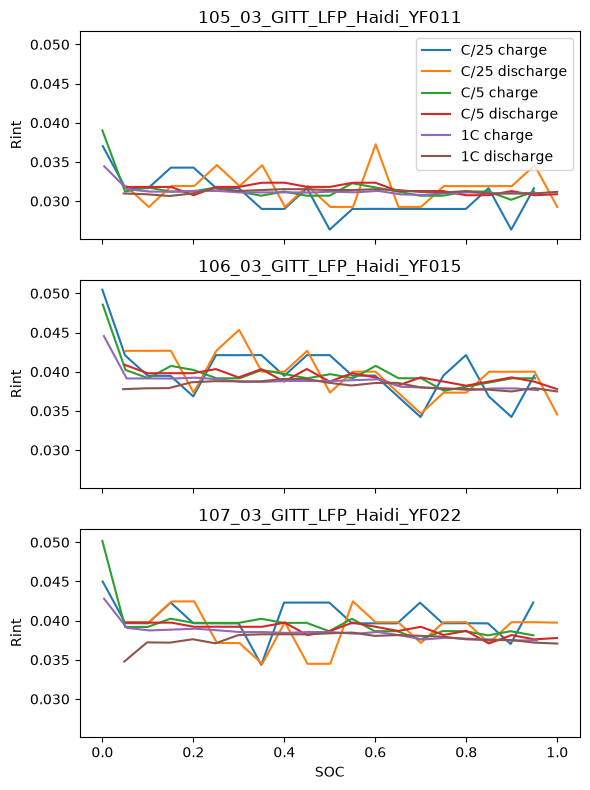

In [ ]:
line_labels = {
    22: "C/25 charge",
    33: "C/25 discharge",
    45: "C/5 charge",
    56: "C/5 discharge",
    68: "1C charge",
    79: "1C discharge",
}

recordings = sorted(result["Recording"].unique())
fig, axes = plt.subplots(len(recordings), 1, sharex=True, sharey=True, figsize=(6,8))

for ax, recording in zip(axes, recordings, strict=False):
    recording_result = result[result["Recording"] == recording]

    for line, group in recording_result.groupby("Line"):
        group = group.sort_values("SOC")

        ax.plot(
            group["SOC"],
            group["Rint[Ohm]"],
            # marker="o",
            label=line_labels[line],
        )

    ax.set_title(recording)
    ax.set_ylabel("Rint")
    # ax.grid()

axes[-1].set_xlabel("SOC")
axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
soc_grid = np.arange(0.0, 1.01, 0.01).tolist()
Rint_lut = []

# C/25 lines dropped due to being noisy
valid_lines = [45, 56, 68, 79]

for_lut = result[result["Line"].isin(valid_lines)].sort_values("SOC").copy()

for_lut["SOC_round"] = (for_lut["SOC"] / 0.05).round() * 0.05

mean_rint = (
    for_lut
    .groupby("SOC_round", as_index=False)
    .agg({"Rint[Ohm]": "mean", "Recording": "nunique"})
    .rename(columns={"Recording": "n_recordings"})
    .sort_values("SOC_round")
)

socs = mean_rint["SOC_round"].tolist()
rints = mean_rint["Rint[Ohm]"].tolist()

for soc in soc_grid:
    rint = interp1d_scalar(soc, socs, rints)

    Rint_lut.append(rint)

In [ ]:
LUT = pd.DataFrame({"SOC": soc_grid, "Rint[Ohm]": Rint_lut})
LUT

,SOC,Rint[Ohm]
0,0.00,0.043256
1,0.01,0.041877
2,0.02,0.040498
3,0.03,0.039119
4,0.04,0.037740
...,...,...
96,0.96,0.035591
97,0.97,0.035534
98,0.98,0.035477
99,0.99,0.035420


Text(0, 0.5, 'Rint')

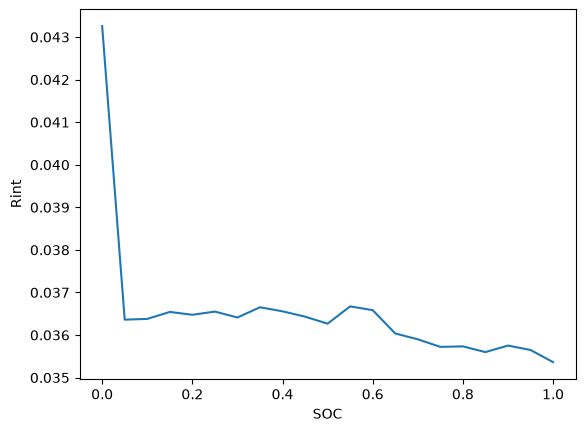

In [ ]:
plt.plot(LUT["SOC"], LUT["Rint[Ohm]"])
plt.xlabel("SOC")
plt.ylabel("Rint")

In [ ]:
# LUT.to_csv(r"../../src/simses/model/cell/data/haidi_rint.csv", index=False)